# DLinear — Walmart Store Sales Forecasting

Model experiment notebook for the DLinear branch of the multi-model comparison
(LightGBM, XGBoost, DLinear, classical stats). DLinear ("Are Transformers
Effective for Time Series Forecasting?", Zeng et al. 2022) decomposes each
series into trend (moving average) and seasonal (residual) components and
fits one linear layer per component — no attention, no recurrence, just two
linear maps. The model and all data-prep logic live in `utils/dlinear.py`,
shared-utils style, same as `utils/feature_engineering.py` for the tree
notebooks.

**Cells written but not executed against this version of the code.** The
first version of this notebook (single validation split, no week-of-year
input) was executed successfully — locally, via a separate `.venv-dlinear`
(Python 3.11 + CPU torch; this project's main `.venv` has no torch wheel
for its Python version) — and produced the holdout WMAE and plots that
motivated the three changes below. Those changes were then implemented and
re-validated against `utils/dlinear.py` with synthetic data (same
throwaway-venv approach as the first version), but this specific set of
cells hasn't been re-run against the real 421,570-row dataset yet — so the
code is believed correct, not confirmed against real numbers.

**How this notebook departs from the LightGBM/XGBoost ones, and why:**

- **Every series, no exceptions.** All 3,331 (Store, Dept) pairs get
  windows in every training set built below — no top-N subsetting anywhere.
  (The tree notebooks' `TOP_N = 20` was a *feature* selection — picking 20
  of 28 candidate columns — never a series/row subsetting; every series was
  always in their training data too. This notebook has no feature-selection
  step at all, so there's nothing analogous to subset.)
- **Global, shared-weight model.** One `DLinear` (two linear layers) is
  fit across all series at once, each series contributing training windows
  rather than getting its own model — this is what makes "train on every
  series" tractable with one small, fast model instead of 3,331 of them.
- **Only `train.csv`/`test.csv`.** No `features.csv`/`stores.csv` — DLinear
  is deliberately just a linear map over each series' own sales history
  (+ a holiday flag, see below), not a tabular model with exogenous
  regressors. A `DLinear+X` variant that also consumes CPI/Fuel_Price/
  markdowns is a natural follow-up, not attempted here.
- **The horizon's future `IsHoliday` flag and a cyclical week-of-year
  encoding are fed to the model directly**, not inferred from lag features.
  Neither is leakage — both are known calendar facts for any future date,
  not a leaky copy of the sales target. `IsHoliday` directly addresses a
  real weakness found in the tree notebooks: their walk-forward CV never
  once validated on Thanksgiving/Christmas, and the gain-based feature
  selection actually *dropped* `IsChristmas` for having zero importance.
  Week-of-year addresses a second, related gap this project's own holdout
  plots exposed: a real, visible demand spike around Easter that no
  `IsHoliday` flag catches (Kaggle only tracks 4 named holidays), and that
  DLinear otherwise has zero calendar-position signal for at all — unlike
  the tree notebooks, which had `WeekOfYear` as a top-20 selected feature.
- **Three validation splits, not the tree notebooks' 3-fold walk-forward
  CV.** A training window needs `LOOKBACK + HORIZON = 52 + 13 = 65`
  consecutive weeks, which rules out the tree notebooks' Fold 1 (52-week
  train) and Fold 2 (65-week train) entirely. Within `local_train_raw`'s 91
  weeks, only a 14-week range of possible train/val boundaries has room for
  even one window (see Step 3) — 3 splits spread across that range replace
  the single split an earlier version of this notebook used, after that
  version's hyperparameter/epoch selection turned out to be dominated by
  single-split noise (see Step 3 for the concrete evidence).
- **Recursive block rollout for longer horizons.** The model predicts
  `HORIZON = 13` weeks directly per call. The 52-week local holdout needs 4
  chained blocks (52 / 13 = 4 exactly); the real 39-week Kaggle `test.csv`
  needs 3 (39 / 13 = 3 exactly) — both convenient exact multiples. Each
  block's own predictions are fed back in as history for the next block, so
  error can compound across blocks — a known limitation of recursive
  multi-step forecasting, flagged here rather than glossed over.
- **Gaps filled with 0, not left as NaN.** Roughly 20% of series have
  missing weeks (see `utils.dlinear.build_full_calendar_panel`'s docstring).
  Fixed-length windows need a literal value at every timestep, so gaps
  become 0 ("no sales recorded"), which is a real simplification — a gap
  more often means "this department didn't exist at this store yet" than
  "sold nothing" — documented rather than silently assumed.

## Table of Contents
1. [Setup](#1)
2. [Local train/test split](#2)
3. [Sequence construction & validation splits](#3)
4. [Model architecture](#4)
5. [Hyperparameter tuning](#5)
6. [MLflow logging](#6)
7. [Plots](#7)
8. [Full pipeline](#8)

<a id='1'></a>
## 1. Setup

In [1]:
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

warnings.filterwarnings('ignore', category=DeprecationWarning)

from utils.dlinear import (
    DLinear, build_full_calendar_panel, compute_series_stats, series_arrays_from_panel,
    SeriesWindowDataset, weighted_mae_loss, recursive_forecast, DLinearForecastPipeline,
)
from utils.feature_engineering import HOLIDAY_DATES
from utils.metrics import wmae

pd.set_option('display.max_columns', 50)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
if device.type == 'cuda':
    print('GPU:', torch.cuda.get_device_name(0))

DATA_DIR = 'data/raw/walmart-recruiting-store-sales-forecasting/'

# features.csv/stores.csv intentionally not loaded — see the intro markdown
# for why this notebook is deliberately history-only (+ IsHoliday).
train = pd.read_csv(DATA_DIR + 'train.csv', parse_dates=['Date'])
test = pd.read_csv(DATA_DIR + 'test.csv', parse_dates=['Date'])

train = train.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

print(f'train : {train.shape}, {train.Date.min().date()} -> {train.Date.max().date()}, '
      f'{train.Date.nunique()} weeks, {train[["Store","Dept"]].drop_duplicates().shape[0]} series')
print(f'test  : {test.shape}, {test.Date.min().date()} -> {test.Date.max().date()}, {test.Date.nunique()} weeks')

device: cpu


train : (421570, 5), 2010-02-05 -> 2012-10-26, 143 weeks, 3331 series
test  : (115064, 4), 2012-11-02 -> 2013-07-26, 39 weeks


<a id='2'></a>
## 2. Local Train/Test Split

Identical split to the LightGBM/XGBoost notebooks (same reasoning: last 52
weeks of `train.csv` held out locally, standing in for the target-less
Kaggle `test.csv` during development, and long enough to cover one of each
named holiday).

In [2]:
unique_dates = np.sort(train['Date'].unique())
cutoff_date = unique_dates[-52]

local_train_raw = train[train['Date'] < cutoff_date].copy()
local_test_raw = train[train['Date'] >= cutoff_date].copy()

print(f'cutoff date (first date held out): {pd.Timestamp(cutoff_date).date()}')
print(f'local_train_raw: {local_train_raw.shape}, {local_train_raw.Date.min().date()} -> {local_train_raw.Date.max().date()}  ({local_train_raw.Date.nunique()} weeks)')
print(f'local_test_raw : {local_test_raw.shape}, {local_test_raw.Date.min().date()} -> {local_test_raw.Date.max().date()}  ({local_test_raw.Date.nunique()} weeks)')

cutoff date (first date held out): 2011-11-04
local_train_raw: (267184, 5), 2010-02-05 -> 2011-10-28  (91 weeks)
local_test_raw : (154386, 5), 2011-11-04 -> 2012-10-26  (52 weeks)


In [3]:
def holidays_in_range(dates_series):
    dates_set = set(pd.to_datetime(dates_series))
    present = {}
    for name, dates in HOLIDAY_DATES.items():
        matched = [d for d in pd.to_datetime(dates) if d in dates_set]
        if matched:
            present[name] = [d.date() for d in matched]
    return present


print('local_train_raw holidays:', holidays_in_range(local_train_raw['Date']))
print('local_test_raw  holidays:', holidays_in_range(local_test_raw['Date']))
print()
print('Kaggle test.csv holidays (reference, no target):', holidays_in_range(test['Date']))

local_train_raw holidays: {'SuperBowl': [datetime.date(2010, 2, 12), datetime.date(2011, 2, 11)], 'LaborDay': [datetime.date(2010, 9, 10), datetime.date(2011, 9, 9)], 'Thanksgiving': [datetime.date(2010, 11, 26)], 'Christmas': [datetime.date(2010, 12, 31)]}


local_test_raw  holidays: {'SuperBowl': [datetime.date(2012, 2, 10)], 'LaborDay': [datetime.date(2012, 9, 7)], 'Thanksgiving': [datetime.date(2011, 11, 25)], 'Christmas': [datetime.date(2011, 12, 30)]}

Kaggle test.csv holidays (reference, no target): {'SuperBowl': [datetime.date(2013, 2, 8)], 'Thanksgiving': [datetime.date(2012, 11, 23)], 'Christmas': [datetime.date(2012, 12, 28)]}


<a id='3'></a>
## 3. Sequence Construction & Validation Splits

`LOOKBACK = 52` weeks of history to predict `HORIZON = 13` weeks directly.
A training window needs `LOOKBACK + HORIZON = 65` consecutive weeks, which
rules out the tree notebooks' Fold 1 (52-week train) and Fold 2 (65-week
train) entirely — only a train range of 65+ weeks leaves room for even one
window. Within `local_train_raw`'s 91 weeks, that leaves `train_end` free to
range from 65 to 78 (any later and the 13-week validation block runs past
week 91) — a 14-week window to pick splits from.

**Three splits, not one** (`CV_SPLIT_TRAIN_WEEKS = [65, 72, 78]`, spread as
evenly as that 14-week range allows): a single validation split turned out
to be a genuinely noisy estimator in the first pass at this notebook — the
winning hyperparameter combo's `best_epoch` came out as 18 during grid
search and 5 when the *same config* was retrained from scratch immediately
after, and `best_epoch` values across the 9 combos ranged from 0 to 34 with
no coherent pattern. Averaging WMAE across 3 independent splits (mirroring
exactly how the tree notebooks average across folds) trades a 3x compute
cost — still seconds per split for a model this size — for a real reduction
in that noise, both for ranking hyperparameter combos and for picking a
training-length epoch count that isn't just whatever one noisy run happened
to produce.

**Deliberately not adding a 4th split covering Thanksgiving/Christmas.**
That's the same idea tried in the XGBoost notebook earlier in this project
(an extra CV fold anchored on the one available Thanksgiving/Christmas
window) — it was reverted there because a single small, high-variance fold
dominated the mean and made the final model *worse*, not better, on the
true holdout. The same risk applies here, probably more so given DLinear's
validation score is already noisier than the tree models' fold WMAE. The 3
splits below still can't validate against Thanksgiving/Christmas at all
(structurally impossible without cannibalizing the only occurrence
available before `local_test_raw`'s cutoff) — a limitation worth remembering
when reading the tuning results, not one this notebook tries to paper over.

Every (Store, Dept) series present in a split's own training range gets
reindexed onto the full weekly calendar and contributes sliding windows —
no series is excluded from any split.

In [4]:
LOOKBACK = 52
HORIZON = 13
CV_SPLIT_TRAIN_WEEKS = [65, 72, 78]

local_train_dates = np.sort(local_train_raw['Date'].unique())


def build_cv_split(train_end):
    tr_dates = local_train_dates[:train_end]
    va_dates = local_train_dates[train_end:train_end + HORIZON]
    assert len(va_dates) == HORIZON, 'val window must be exactly one HORIZON block for a direct (non-recursive) validation score'

    tr_df = local_train_raw[local_train_raw['Date'].isin(tr_dates)]
    va_df = local_train_raw[local_train_raw['Date'].isin(va_dates)]

    panel = build_full_calendar_panel(tr_df)
    stats = compute_series_stats(panel)
    arrays = series_arrays_from_panel(panel)
    train_ds = SeriesWindowDataset(arrays, stats, LOOKBACK, HORIZON)

    # val panel needs tr_df's tail as history (for the model's LOOKBACK window)
    # plus va_df itself as the target — same pattern as the single-split version.
    val_panel = build_full_calendar_panel(pd.concat([tr_df, va_df], ignore_index=True))
    val_arrays = series_arrays_from_panel(val_panel)

    n_val_only = sum(1 for k in val_arrays if k not in stats)

    return {
        'train_end': train_end, 'tr_dates': tr_dates, 'va_dates': va_dates,
        'stats': stats, 'train_ds': train_ds, 'val_arrays': val_arrays,
        'n_val_only': n_val_only,
    }


cv_splits = [build_cv_split(te) for te in CV_SPLIT_TRAIN_WEEKS]

for s in cv_splits:
    n_series = len(s['stats'])
    print(f"split train_end={s['train_end']}: train {pd.Timestamp(s['tr_dates'][0]).date()} -> {pd.Timestamp(s['tr_dates'][-1]).date()} "
          f"({len(s['tr_dates'])} wks) | val {pd.Timestamp(s['va_dates'][0]).date()} -> {pd.Timestamp(s['va_dates'][-1]).date()} "
          f"holidays={list(holidays_in_range(s['va_dates']).keys())}")
    print(f"  {n_series} series, {len(s['train_ds'])} windows ({len(s['train_ds']) / n_series:.0f} per series), "
          f"{s['n_val_only']} val-only series skipped during scoring (no training-period history)")

split train_end=65: train 2010-02-05 -> 2011-04-29 (65 wks) | val 2011-05-06 -> 2011-07-29 holidays=[]
  3228 series, 3228 windows (1 per series), 13 val-only series skipped during scoring (no training-period history)
split train_end=72: train 2010-02-05 -> 2011-06-17 (72 wks) | val 2011-06-24 -> 2011-09-16 holidays=['LaborDay']
  3235 series, 25880 windows (8 per series), 13 val-only series skipped during scoring (no training-period history)
split train_end=78: train 2010-02-05 -> 2011-07-29 (78 wks) | val 2011-08-05 -> 2011-10-28 holidays=['LaborDay']
  3241 series, 45374 windows (14 per series), 13 val-only series skipped during scoring (no training-period history)


Baseline DLinear (default hyperparameters — `kernel_size=25`,
`learning_rate=1e-3`) across all 3 splits, to confirm the training loop and
evaluation harness work end-to-end and produce a sane mean WMAE before the
grid search (Step 5) builds on top of it — same purpose as the tree
notebooks' Step 3 baseline run, just averaged over splits the same way
theirs is averaged over folds.

In [5]:
def evaluate_val_wmae(model, stats, train_weeks, val_arrays, lookback, horizon, device):
    """WMAE on ONE direct HORIZON-length prediction per series (no recursion —
    val_arrays' window from train_weeks to train_weeks+horizon is exactly one
    block by construction, see the assert above). Series with zero rows in the
    training window (no stats to normalize with) are skipped."""
    preds, trues, holidays = [], [], []
    model.eval()
    with torch.no_grad():
        for key, (sales, holiday, dates) in val_arrays.items():
            if key not in stats:
                continue
            mean, std = stats[key]
            hist_norm = (sales[:train_weeks][-lookback:] - mean) / std
            fut_holiday = holiday[train_weeks: train_weeks + horizon]
            fut_dates = dates[train_weeks: train_weeks + horizon]
            target_raw = sales[train_weeks: train_weeks + horizon]
            pred_norm = recursive_forecast(model, hist_norm, fut_holiday, fut_dates, lookback, horizon, n_blocks=1, device=device)
            pred_raw = np.clip(pred_norm * std + mean, 0, None)
            preds.extend(pred_raw); trues.extend(target_raw); holidays.extend(fut_holiday)
    return wmae(trues, preds, holidays)


def train_model(train_ds, stats, val_arrays, train_weeks, lookback, horizon, kernel_size, learning_rate,
                 max_epochs, patience, batch_size, device, log_mlflow_prefix=None, verbose=False):
    """Trains one model with early stopping on val WMAE. Returns (model,
    best_val_wmae, best_epoch, history). n_aux_channels=horizon*3: future
    IsHoliday + week-of-year sin + week-of-year cos (see utils/dlinear.py's
    build_aux_features) — is_holiday_b is sliced back out of the wider aux
    tensor for the WMAE-weighted loss, which only cares about the holiday flag.
    If log_mlflow_prefix is set, logs f'{prefix}_val_wmae' per epoch to the
    currently-open MLflow run (used by DLinear_CV, Step 6)."""
    dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    model = DLinear(lookback, horizon, kernel_size=kernel_size, n_aux_channels=horizon * 3).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_val, best_state, best_epoch, no_improve, history = np.inf, None, 0, 0, []
    for epoch in range(max_epochs):
        model.train()
        for hist_b, aux_b, target_b in dl:
            hist_b, aux_b, target_b = hist_b.to(device), aux_b.to(device), target_b.to(device)
            opt.zero_grad()
            is_holiday_b = aux_b[:, :horizon]
            loss = weighted_mae_loss(model(hist_b, aux_b), target_b, is_holiday_b)
            loss.backward()
            opt.step()
        val_wmae = evaluate_val_wmae(model, stats, train_weeks, val_arrays, lookback, horizon, device)
        history.append(val_wmae)
        if log_mlflow_prefix:
            mlflow.log_metric(f'{log_mlflow_prefix}_val_wmae', val_wmae, step=epoch)
        if val_wmae < best_val - 1e-3:
            best_val, best_epoch, no_improve = val_wmae, epoch, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            no_improve += 1
            if no_improve >= patience:
                break
        if verbose and epoch % 10 == 0:
            print(f'  epoch {epoch:3d}: val WMAE = {val_wmae:.2f} (best {best_val:.2f} @ epoch {best_epoch})')
    model.load_state_dict(best_state)
    return model, best_val, best_epoch, history


def train_and_score_across_splits(cv_splits, kernel_size, learning_rate, max_epochs, patience, batch_size, device,
                                   log_mlflow=False, verbose=False):
    """Trains one fresh model per split (mirrors the tree notebooks' per-fold
    pattern exactly), returns (mean_val_wmae, per_split_wmaes, per_split_epochs).
    per_split_epochs is 3 independent best_epoch draws for the same
    hyperparameters — used later (Step 5/6) as a robust epoch-count estimate
    instead of trusting a single noisy run."""
    split_wmaes, split_epochs = [], []
    for i, s in enumerate(cv_splits):
        prefix = f'split{i}' if log_mlflow else None
        _, val_wmae, best_epoch, _ = train_model(
            s['train_ds'], s['stats'], s['val_arrays'], s['train_end'], LOOKBACK, HORIZON,
            kernel_size, learning_rate, max_epochs, patience, batch_size, device,
            log_mlflow_prefix=prefix, verbose=verbose,
        )
        split_wmaes.append(val_wmae)
        split_epochs.append(best_epoch)
    return float(np.mean(split_wmaes)), split_wmaes, split_epochs


BASELINE_PARAMS = dict(kernel_size=25, learning_rate=1e-3)
MAX_EPOCHS = 200
PATIENCE = 15
BATCH_SIZE = 512

print('Training baseline DLinear across all 3 splits...')
baseline_val_wmae, baseline_split_wmaes, baseline_split_epochs = train_and_score_across_splits(
    cv_splits, **BASELINE_PARAMS, max_epochs=MAX_EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE, device=device,
)
print(f'Baseline mean val WMAE: {baseline_val_wmae:.2f}  (per-split: {[round(w, 1) for w in baseline_split_wmaes]}, '
      f'best epochs: {baseline_split_epochs})')

Training baseline DLinear across all 3 splits...


Baseline mean val WMAE: 2421.64  (per-split: [2373.0, 2503.0, 2388.9], best epochs: [5, 0, 17])


<a id='4'></a>
## 4. Model Architecture

`utils.dlinear.DLinear`: a `SeriesDecomp` block splits the normalized
`(batch, LOOKBACK, 1)` history into `trend` (centered moving average,
`kernel_size` wide) and `seasonal` (the residual), then two `nn.Linear`
layers — `Linear_Seasonal` and `Linear_Trend`, each `(LOOKBACK + HORIZON*3)
-> HORIZON` — map each component straight to the forecast; the two outputs
are summed. `n_aux_channels=HORIZON*3` widens both layers' input to also
take, for the block being predicted: `HORIZON` future `IsHoliday` flags,
`HORIZON` week-of-year sine values, and `HORIZON` week-of-year cosine values
— concatenated in that fixed order by `utils.dlinear.build_aux_features`,
the single place this layout is defined so training and inference can never
silently drift apart.

**Why week-of-year, and why sin/cos, not a raw integer**: `IsHoliday`
targets Thanksgiving/Christmas/SuperBowl/LaborDay specifically. Everything
else with a recurring calendar pattern — Easter being the clearest example
visible in this project's own holdout plots (Plot 1) — gets no signal at
all otherwise, since this DLinear has no `Month`/`WeekOfYear` input, unlike
both tree notebooks (`WeekOfYear` was a top-20 selected feature for each). A
raw integer week (1-52) would also make week 52 and week 1 look maximally
far apart to a linear model, when they're calendar-adjacent — sin/cos
encodes the cyclical structure directly. This is a soft, not exact, fix for
Easter specifically, since its calendar date drifts year to year and
week-of-year can only encode "usually happens somewhere around here," not
pin an exact week — but it's a real improvement over having no
calendar-position signal at all.

Every series shares the same two linear layers (`individual=False` in the
original paper's terms) — there's no per-series capacity at all, which is
the whole point: one small model generalizes across all series rather than
needing one each. This is also why feature selection (tree notebooks' Step
4) has no analogue here — there are only ever two *kinds* of input (own
sales history, future calendar covariates), nothing to rank or drop.

In [6]:
_demo_model = DLinear(lookback=LOOKBACK, horizon=HORIZON, kernel_size=25, n_aux_channels=HORIZON * 3)
n_params = sum(p.numel() for p in _demo_model.parameters())
print(f'DLinear(lookback={LOOKBACK}, horizon={HORIZON}, kernel_size=25, n_aux_channels={HORIZON * 3}): {n_params} parameters')
print(_demo_model)
del _demo_model

DLinear(lookback=52, horizon=13, kernel_size=25, n_aux_channels=39): 2392 parameters
DLinear(
  (decomp): SeriesDecomp(
    (moving_avg): MovingAvg(
      (avg): AvgPool1d(kernel_size=(25,), stride=(1,), padding=(0,))
    )
  )
  (Linear_Seasonal): Linear(in_features=91, out_features=13, bias=True)
  (Linear_Trend): Linear(in_features=91, out_features=13, bias=True)
)


<a id='5'></a>
## 5. Hyperparameter Tuning (manual grid, WMAE-scored)

Same 9-combo grid as before (`kernel_size` and `learning_rate` are the only
two hyperparameters that change DLinear's capacity/behavior at all):

| Param | Values |
|---|---|
| `kernel_size` | 13, 25, 37 |
| `learning_rate` | 1e-2, 3e-3, 1e-3 |

Each combo now trains **3 independent models, one per split** (early
stopping per-split, `patience=15`, `max_epochs=200`), ranked by **mean WMAE
across the 3 splits** — 27 fits total instead of 9, still seconds each.
Alongside the mean, each combo's 3 `best_epoch` values are kept — for the
winning combo, their **median** becomes the fixed epoch count reused in
Step 7/8, rather than trusting whichever number one retrain happens to
produce (see Step 3 for why the single-split version of this was
unreliable).

In [7]:
param_grid = {
    'kernel_size': [13, 25, 37],
    'learning_rate': [1e-2, 3e-3, 1e-3],
}
param_names = list(param_grid.keys())
param_combos = list(itertools.product(*param_grid.values()))
print(f'{len(param_combos)} hyperparameter combinations x {len(cv_splits)} splits = {len(param_combos) * len(cv_splits)} fits')

9 hyperparameter combinations x 3 splits = 27 fits


In [8]:
grid_results = []
for combo_idx, combo_values in enumerate(param_combos, start=1):
    params = dict(zip(param_names, combo_values))
    mean_wmae, split_wmaes, split_epochs = train_and_score_across_splits(
        cv_splits, **params, max_epochs=MAX_EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE, device=device,
    )
    grid_results.append({
        **params, 'mean_val_wmae': mean_wmae, 'split_wmaes': split_wmaes, 'split_epochs': split_epochs,
    })
    print(f'[{combo_idx:2d}/{len(param_combos)}] {params} -> mean_val_wmae={mean_wmae:.2f}  '
          f'(per-split: {[round(w, 1) for w in split_wmaes]}, best epochs: {split_epochs})')

grid_results_df = pd.DataFrame(grid_results).sort_values('mean_val_wmae').reset_index(drop=True)
grid_results_df[['kernel_size', 'learning_rate', 'mean_val_wmae', 'split_wmaes', 'split_epochs']]

[ 1/9] {'kernel_size': 13, 'learning_rate': 0.01} -> mean_val_wmae=2511.03  (per-split: [2527.0, 2617.9, 2388.2], best epochs: [0, 2, 5])


[ 2/9] {'kernel_size': 13, 'learning_rate': 0.003} -> mean_val_wmae=2560.77  (per-split: [2732.0, 2544.1, 2406.2], best epochs: [1, 0, 9])


[ 3/9] {'kernel_size': 13, 'learning_rate': 0.001} -> mean_val_wmae=2431.71  (per-split: [2443.5, 2418.7, 2432.9], best epochs: [8, 1, 0])


[ 4/9] {'kernel_size': 25, 'learning_rate': 0.01} -> mean_val_wmae=2422.31  (per-split: [2446.3, 2434.7, 2385.9], best epochs: [0, 0, 1])


[ 5/9] {'kernel_size': 25, 'learning_rate': 0.003} -> mean_val_wmae=2459.72  (per-split: [2555.4, 2462.6, 2361.2], best epochs: [2, 0, 6])


[ 6/9] {'kernel_size': 25, 'learning_rate': 0.001} -> mean_val_wmae=2420.50  (per-split: [2417.7, 2450.4, 2393.4], best epochs: [6, 1, 9])


[ 7/9] {'kernel_size': 37, 'learning_rate': 0.01} -> mean_val_wmae=2520.08  (per-split: [2538.4, 2612.4, 2409.5], best epochs: [0, 9, 0])


[ 8/9] {'kernel_size': 37, 'learning_rate': 0.003} -> mean_val_wmae=2481.87  (per-split: [2576.5, 2455.7, 2413.4], best epochs: [2, 0, 1])


[ 9/9] {'kernel_size': 37, 'learning_rate': 0.001} -> mean_val_wmae=2459.62  (per-split: [2399.6, 2547.2, 2432.1], best epochs: [6, 9, 9])


,kernel_size,learning_rate,mean_val_wmae,split_wmaes,split_epochs
0,25,0.001,2420.496973,"[2417.7065706797434, 2450.3635493548113, 2393....","[6, 1, 9]"
1,25,0.010,2422.305258,"[2446.327893384719, 2434.6766912891158, 2385.9...","[0, 0, 1]"
2,13,0.001,2431.706477,"[2443.534636633766, 2418.7127137298216, 2432.8...","[8, 1, 0]"
3,37,0.001,2459.624285,"[2399.598023536917, 2547.1807851982744, 2432.0...","[6, 9, 9]"
4,25,0.003,2459.722435,"[2555.3845439290894, 2462.5561616502314, 2361....","[2, 0, 6]"
5,37,0.003,2481.865669,"[2576.5090682988343, 2455.7016641989444, 2413....","[2, 0, 1]"
6,13,0.010,2511.029290,"[2527.0380437395083, 2617.8537289664714, 2388....","[0, 2, 5]"
7,37,0.010,2520.083600,"[2538.389214260754, 2612.383542122752, 2409.47...","[0, 9, 0]"
8,13,0.003,2560.773562,"[2731.983703129919, 2544.096135148284, 2406.24...","[1, 0, 9]"


In [9]:
best_params = {k: grid_results_df.loc[0, k] for k in param_names}
best_val_wmae = grid_results_df.loc[0, 'mean_val_wmae']
best_split_epochs = grid_results_df.loc[0, 'split_epochs']
median_best_epoch = int(round(np.median(best_split_epochs)))

print('Best params:', best_params)
print(f'Best mean val WMAE: {best_val_wmae:.2f} (vs baseline: {baseline_val_wmae:.2f})')
print(f'Best epochs per split: {best_split_epochs} -> median {median_best_epoch} '
      f'(reused as a fixed training length once Step 7/8 have no validation set left)')

Best params: {'kernel_size': 25, 'learning_rate': 0.001}
Best mean val WMAE: 2420.50 (vs baseline: 2421.64)
Best epochs per split: [6, 1, 9] -> median 6 (reused as a fixed training length once Step 7/8 have no validation set left)


<a id='6'></a>
## 6. MLflow Logging (DagsHub-hosted)

Same DagsHub-hosted MLflow server as the LightGBM/XGBoost notebooks,
separate experiment `DLinear_Training`. Five runs:

1. `DLinear_Cleaning` — data shape and the local train/test split (Step 2)
2. `DLinear_Windowing` — sequence-construction config and per-split dataset sizes (Step 3)
3. `DLinear_CV_Tuning` — the 27-fit grid search (Step 5), batched summary
4. `DLinear_CV` — genuinely incremental: retrains the winning config across all 3 splits once more, logging each split's `val_wmae` after every epoch as it happens
5. `DLinear_Final_Fit` — the full pipeline (Step 8)

Plot artifacts are skipped (params/metrics only), same choice as the other
two notebooks.

In [10]:
import dagshub

dagshub.init(repo_owner='tgela23', repo_name='ml-final-project', mlflow=True)

import mlflow
mlflow.set_experiment('DLinear_Training')
print('tracking uri:', mlflow.get_tracking_uri())

Accessing as tgela23

Initialized MLflow to track repo "tgela23/ml-final-project"

Repository tgela23/ml-final-project initialized!

tracking uri: https://dagshub.com/tgela23/ml-final-project.mlflow


**Run 1 — `DLinear_Cleaning`**

In [11]:
with mlflow.start_run(run_name='DLinear_Cleaning'):
    mlflow.log_param('train_csv_shape', str(train.shape))
    mlflow.log_param('test_csv_shape', str(test.shape))
    mlflow.log_param('train_date_range', f'{train.Date.min().date()} -> {train.Date.max().date()}')

    mlflow.log_param('local_test_holdout_weeks', 52)
    mlflow.log_param('local_train_date_range', f'{local_train_raw.Date.min().date()} -> {local_train_raw.Date.max().date()}')
    mlflow.log_param('local_test_date_range', f'{local_test_raw.Date.min().date()} -> {local_test_raw.Date.max().date()}')

    mlflow.log_metric('n_train_rows', len(train))
    mlflow.log_metric('n_local_train_rows', len(local_train_raw))
    mlflow.log_metric('n_local_test_rows', len(local_test_raw))
    mlflow.log_metric('n_stores', train['Store'].nunique())
    mlflow.log_metric('n_depts', train['Dept'].nunique())
    mlflow.log_metric('n_series', train[['Store', 'Dept']].drop_duplicates().shape[0])

print('DLinear_Cleaning run logged.')

🏃 View run DLinear_Cleaning at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3/runs/2b4cce765e7441f3a230eafb13f92a58
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3


DLinear_Cleaning run logged.


**Run 2 — `DLinear_Windowing`**

In [12]:
with mlflow.start_run(run_name='DLinear_Windowing'):
    mlflow.log_param('lookback', LOOKBACK)
    mlflow.log_param('horizon', HORIZON)
    mlflow.log_param('cv_split_train_weeks', str(CV_SPLIT_TRAIN_WEEKS))
    mlflow.log_param('aux_channels', 'future IsHoliday + week-of-year sin/cos')

    for i, s in enumerate(cv_splits):
        mlflow.log_metric(f'split{i}_train_end', s['train_end'])
        mlflow.log_metric(f'split{i}_n_windows', len(s['train_ds']))
    mlflow.log_metric('baseline_val_wmae', baseline_val_wmae)

print('DLinear_Windowing run logged.')

🏃 View run DLinear_Windowing at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3/runs/3257b32382114b2bbbc9775c18cee8a8
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3


DLinear_Windowing run logged.


**Run 3 — `DLinear_CV_Tuning`**: batched summary of the 27-fit grid search.

In [13]:
with mlflow.start_run(run_name='DLinear_CV_Tuning'):
    mlflow.log_param('param_grid', str(param_grid))

    for i, row in grid_results_df.iterrows():
        mlflow.log_metric('combo_mean_val_wmae', row['mean_val_wmae'], step=i)

    mlflow.log_params({f'best_{k}': v for k, v in best_params.items()})
    mlflow.log_metric('best_mean_val_wmae', best_val_wmae)
    mlflow.log_metric('median_best_epoch', median_best_epoch)

print('DLinear_CV_Tuning run logged.')

🏃 View run DLinear_CV_Tuning at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3/runs/b74866cccae945559ec4f9eb4eb9ae06
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3


DLinear_CV_Tuning run logged.


**Run 4 — `DLinear_CV`**: genuinely incremental companion to
`DLinear_CV_Tuning` — retrains the winning hyperparameters across all 3
splits from scratch and logs each split's `val_wmae` after every epoch
inside the open run, as it happens.

In [14]:
with mlflow.start_run(run_name='DLinear_CV'):
    mlflow.log_params(best_params)
    mlflow.log_param('max_epochs', MAX_EPOCHS)
    mlflow.log_param('patience', PATIENCE)
    mlflow.log_param('batch_size', BATCH_SIZE)

    tuned_val_wmae, tuned_split_wmaes, tuned_split_epochs = train_and_score_across_splits(
        cv_splits, **best_params, max_epochs=MAX_EPOCHS, patience=PATIENCE, batch_size=BATCH_SIZE, device=device,
        log_mlflow=True,
    )

    mlflow.log_metric('final_mean_val_wmae', tuned_val_wmae)
    for i, e in enumerate(tuned_split_epochs):
        mlflow.log_metric(f'final_split{i}_best_epoch', e)

print(f'DLinear_CV run logged. mean val WMAE = {tuned_val_wmae:.2f} '
      f'(per-split: {[round(w, 1) for w in tuned_split_wmaes]}, best epochs: {tuned_split_epochs})')

🏃 View run DLinear_CV at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3/runs/5797f5e84b70420a8c1f83010373438a
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3


DLinear_CV run logged. mean val WMAE = 2358.76 (per-split: [2361.9, 2308.6, 2405.8], best epochs: [5, 0, 10])


<a id='7'></a>
## 7. Plots

`N_EPOCHS_FINAL` is the **median** of Run 4's 3 fresh per-split `best_epoch`
draws (`tuned_split_epochs`), plus one — not a single noisy retrain's
number, and not the grid search's own `median_best_epoch` either (Run 4's
fresh retrain is treated as canonical, same convention the original
single-split version used, just made robust now). Refit once at the tuned
hyperparameters on all 91 weeks of `local_train_raw` for that many fixed
epochs — there's no more validation data at this stage to early-stop
against, same reasoning the tree notebooks used for `best_n_estimators`.
Evaluated on `local_test_raw` (52 weeks, genuinely out-of-sample) via the
4-block recursive rollout. All plots saved to `plots/` with a `_dlinear`
suffix.

In [15]:
def train_fixed_epochs(train_ds, lookback, horizon, kernel_size, learning_rate, n_epochs, batch_size, device):
    """No validation set available at this stage — trains for exactly
    n_epochs (found via early stopping on the CV validation splits in Step 6),
    rather than early-stopping again."""
    dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    model = DLinear(lookback, horizon, kernel_size=kernel_size, n_aux_channels=horizon * 3).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=learning_rate)
    model.train()
    for _epoch in range(n_epochs):
        for hist_b, aux_b, target_b in dl:
            hist_b, aux_b, target_b = hist_b.to(device), aux_b.to(device), target_b.to(device)
            opt.zero_grad()
            is_holiday_b = aux_b[:, :horizon]
            loss = weighted_mae_loss(model(hist_b, aux_b), target_b, is_holiday_b)
            loss.backward()
            opt.step()
    return model


def predict_holdout_all_series(model, stats, arrays, train_weeks, n_test_weeks, lookback, horizon, device):
    """Recursive rollout for every series, returned as a plotting-ready
    Store/Dept/Date/Actual/Predicted/IsHoliday dataframe, plus a count of
    series skipped for having zero rows in the training window."""
    n_blocks = int(np.ceil(n_test_weeks / horizon))
    rows = []
    n_skipped = 0
    for key, (sales, holiday, dates_arr) in arrays.items():
        if key not in stats:
            n_skipped += 1
            continue
        mean, std = stats[key]
        hist_norm = (sales[:train_weeks][-lookback:] - mean) / std
        fut_holiday = holiday[train_weeks: train_weeks + n_blocks * horizon]
        fut_dates = dates_arr[train_weeks: train_weeks + n_blocks * horizon]
        pred_norm = recursive_forecast(model, hist_norm, fut_holiday, fut_dates, lookback, horizon, n_blocks, device)
        pred_raw = np.clip(pred_norm[:n_test_weeks] * std + mean, 0, None)
        test_dates = dates_arr[train_weeks: train_weeks + n_test_weeks]
        test_actual = sales[train_weeks: train_weeks + n_test_weeks]
        test_holiday = holiday[train_weeks: train_weeks + n_test_weeks].astype(bool)
        for d, a, p, h in zip(test_dates, test_actual, pred_raw, test_holiday):
            rows.append((key[0], key[1], pd.Timestamp(d), a, p, h))
    df = pd.DataFrame(rows, columns=['Store', 'Dept', 'Date', 'Actual', 'Predicted', 'IsHoliday'])
    return df, n_skipped

In [16]:
median_tuned_epoch = int(round(np.median(tuned_split_epochs)))
N_EPOCHS_FINAL = median_tuned_epoch + 1

eval_panel = build_full_calendar_panel(local_train_raw)
eval_stats = compute_series_stats(eval_panel)
eval_arrays = series_arrays_from_panel(eval_panel)
eval_train_ds = SeriesWindowDataset(eval_arrays, eval_stats, LOOKBACK, HORIZON)

print(f'Training final holdout-eval model for {N_EPOCHS_FINAL} fixed epochs '
      f'(median of {tuned_split_epochs} + 1) on {len(eval_train_ds)} windows...')
holdout_model = train_fixed_epochs(
    eval_train_ds, LOOKBACK, HORIZON, **best_params, n_epochs=N_EPOCHS_FINAL, batch_size=BATCH_SIZE, device=device,
)

holdout_panel = build_full_calendar_panel(pd.concat([local_train_raw, local_test_raw], ignore_index=True))
holdout_arrays = series_arrays_from_panel(holdout_panel)

pred_df, n_skipped = predict_holdout_all_series(
    holdout_model, eval_stats, holdout_arrays,
    train_weeks=len(local_train_dates), n_test_weeks=local_test_raw['Date'].nunique(),
    lookback=LOOKBACK, horizon=HORIZON, device=device,
)
if n_skipped:
    print(f'{n_skipped} series skipped (present in local_test_raw but zero rows in local_train_raw — '
          f'no training-period stats/history to forecast from).')
pred_df['Residual'] = pred_df['Actual'] - pred_df['Predicted']

holdout_wmae = wmae(pred_df['Actual'], pred_df['Predicted'], pred_df['IsHoliday'])
print(f'Local-test holdout WMAE (tuned model, 52 weeks, recursive 4-block rollout): {holdout_wmae:.2f}')

Training final holdout-eval model for 6 fixed epochs (median of [5, 0, 10] + 1) on 87858 windows...


77 series skipped (present in local_test_raw but zero rows in local_train_raw — no training-period stats/history to forecast from).
Local-test holdout WMAE (tuned model, 52 weeks, recursive 4-block rollout): 2532.49


**Plot 1 — Actual vs. predicted over time**, the same 3 sample Store/Dept
series used in the LightGBM/XGBoost notebooks, across the local-test
holdout.

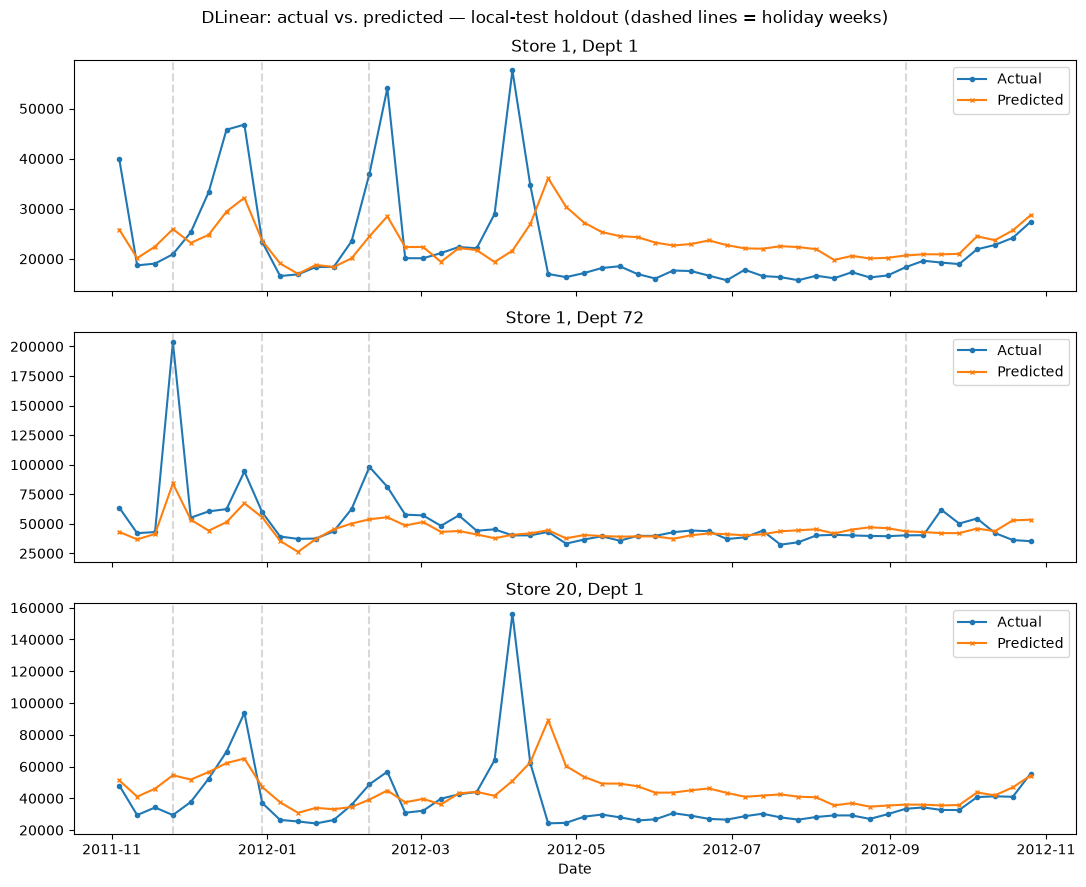

In [17]:
sample_combos = [(1, 1), (1, 72), (20, 1)]

fig, axes = plt.subplots(len(sample_combos), 1, figsize=(11, 9), sharex=True)
for ax, (store, dept) in zip(axes, sample_combos):
    sub = pred_df[(pred_df['Store'] == store) & (pred_df['Dept'] == dept)].sort_values('Date')
    ax.plot(sub['Date'], sub['Actual'], label='Actual', marker='o', markersize=3)
    ax.plot(sub['Date'], sub['Predicted'], label='Predicted', marker='x', markersize=3)
    holiday_dates = sub.loc[sub['IsHoliday'], 'Date']
    for hd in holiday_dates:
        ax.axvline(hd, color='gray', alpha=0.3, linestyle='--')
    ax.set_title(f'Store {store}, Dept {dept}')
    ax.legend()
ax.set_xlabel('Date')
fig.suptitle('DLinear: actual vs. predicted — local-test holdout (dashed lines = holiday weeks)')
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted_timeseries_dlinear.png', dpi=150, bbox_inches='tight')
plt.show()

**Plot 2 — Learned linear weights**, DLinear's analogue of a feature
importance plot: the average magnitude each input position gets from the
`Linear_Seasonal`/`Linear_Trend` layers, averaged over the 13 output steps.
Positions 0-51 are the 52 lookback lags, 52-64 are the future `IsHoliday`
flags, 65-77 are future week-of-year sine, 78-90 are future week-of-year
cosine.

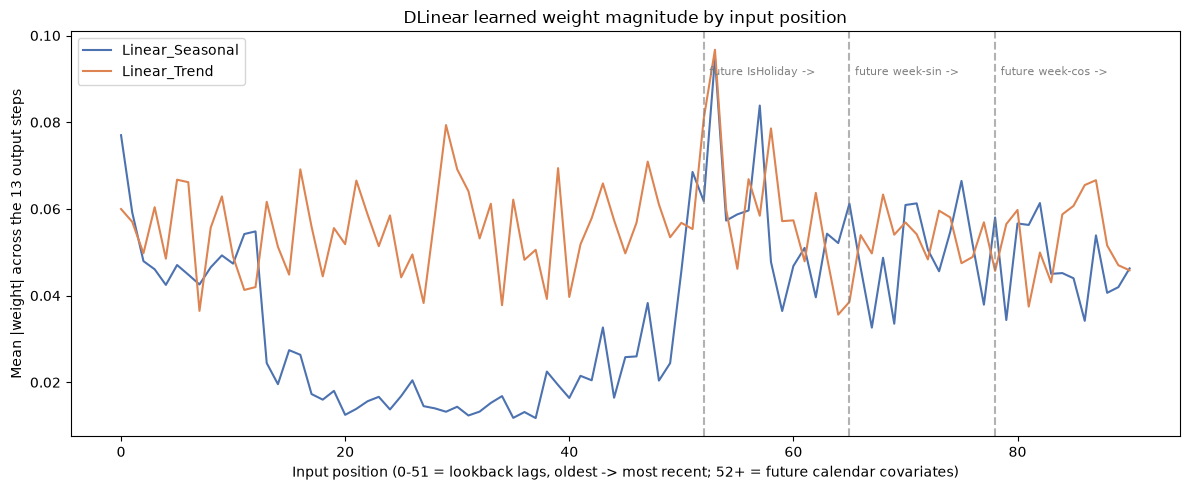

In [18]:
def mean_abs_weight(layer):
    return layer.weight.detach().cpu().abs().mean(dim=0).numpy()  # (in_features,)

seasonal_w = mean_abs_weight(holdout_model.Linear_Seasonal)
trend_w = mean_abs_weight(holdout_model.Linear_Trend)
x = np.arange(len(seasonal_w))
boundaries = [LOOKBACK, LOOKBACK + HORIZON, LOOKBACK + 2 * HORIZON]  # lookback | holiday | sin | cos
boundary_labels = ['future IsHoliday ->', 'future week-sin ->', 'future week-cos ->']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, seasonal_w, label='Linear_Seasonal', color='#4C72B0')
ax.plot(x, trend_w, label='Linear_Trend', color='#DD8452')
for b, label in zip(boundaries, boundary_labels):
    ax.axvline(b, color='gray', linestyle='--', alpha=0.6)
    ax.text(b + 0.5, ax.get_ylim()[1] * 0.9, label, fontsize=8, color='gray')
ax.set_xlabel('Input position (0-51 = lookback lags, oldest -> most recent; 52+ = future calendar covariates)')
ax.set_ylabel('Mean |weight| across the 13 output steps')
ax.set_title('DLinear learned weight magnitude by input position')
ax.legend()
plt.tight_layout()
plt.savefig('plots/feature_importance_tuned_dlinear.png', dpi=150)
plt.show()

**Plot 3 — WMAE by stage**: baseline (untuned, mean across splits) vs.
tuned (mean across splits) vs. final holdout — the DLinear analogue of the
tree notebooks' "WMAE by fold" plot.

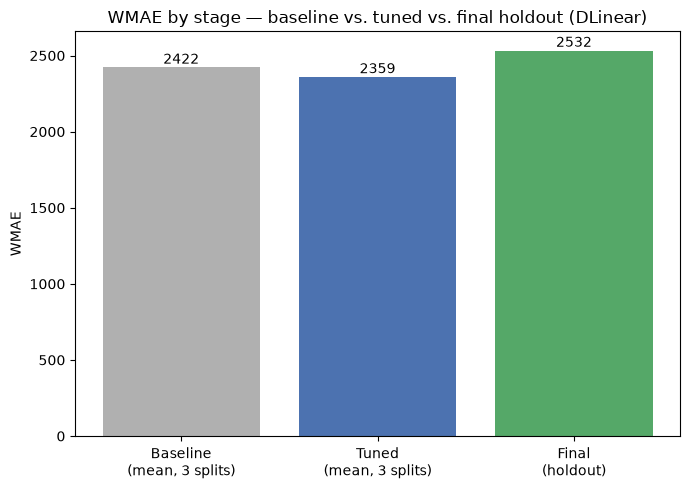

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
stages = ['Baseline\n(mean, 3 splits)', 'Tuned\n(mean, 3 splits)', 'Final\n(holdout)']
values = [baseline_val_wmae, tuned_val_wmae, holdout_wmae]
colors = ['#B0B0B0', '#4C72B0', '#55A868']
ax.bar(stages, values, color=colors)
for i, v in enumerate(values):
    ax.text(i, v + max(values) * 0.01, f'{v:.0f}', ha='center')
ax.set_ylabel('WMAE')
ax.set_title('WMAE by stage — baseline vs. tuned vs. final holdout (DLinear)')
plt.tight_layout()
plt.savefig('plots/wmae_by_fold_dlinear.png', dpi=150)
plt.show()

**Plot 4 — Residual distribution** on the local-test holdout.

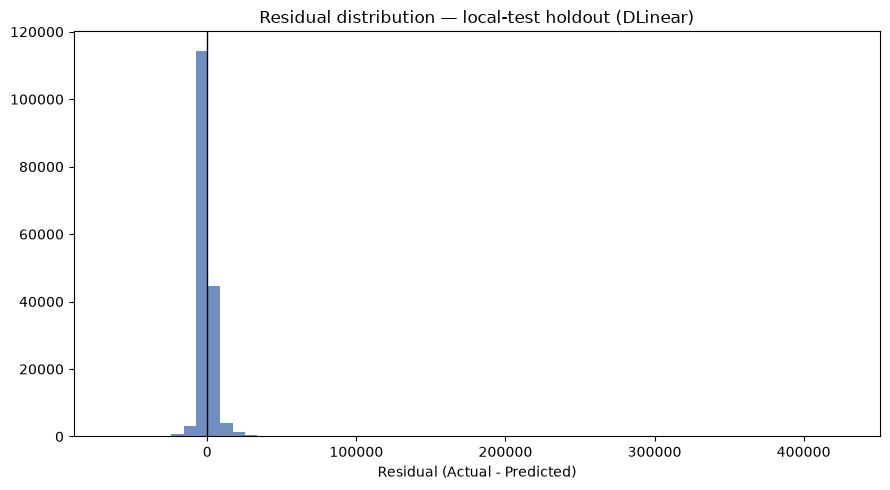

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(pred_df['Residual'], bins=60, color='#4C72B0', alpha=0.8)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Residual (Actual - Predicted)')
ax.set_title('Residual distribution — local-test holdout (DLinear)')
plt.tight_layout()
plt.savefig('plots/residual_distribution_dlinear.png', dpi=150)
plt.show()

**Plot 5 — Actual vs. predicted, holiday vs. non-holiday weeks**

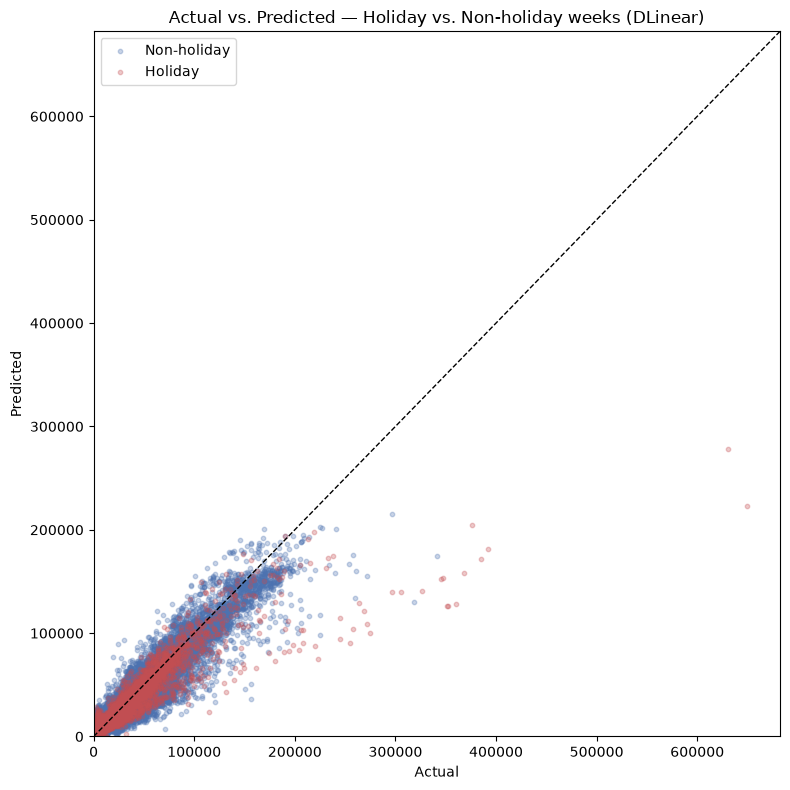

In [21]:
fig, ax = plt.subplots(figsize=(8, 8))
for is_holiday, color, label in [(False, '#4C72B0', 'Non-holiday'), (True, '#C44E52', 'Holiday')]:
    sub = pred_df[pred_df['IsHoliday'] == is_holiday]
    ax.scatter(sub['Actual'], sub['Predicted'], alpha=0.3, s=10, color=color, label=label)
lims = [0, pred_df[['Actual', 'Predicted']].to_numpy().max() * 1.05]
ax.plot(lims, lims, color='black', linewidth=1, linestyle='--')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
ax.set_title('Actual vs. Predicted — Holiday vs. Non-holiday weeks (DLinear)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/actual_vs_predicted_holiday_dlinear.png', dpi=150)
plt.show()

<a id='8'></a>
## 8. Full Pipeline

`utils.dlinear.DLinearForecastPipeline` is the DLinear analogue of the tree
notebooks' `sklearn.pipeline.Pipeline`: `fit()` stores every series' full
history and per-series normalization stats; `predict()` takes bare
`Store/Dept/Date/IsHoliday` rows (e.g. `test.csv` exactly as downloaded) and
handles reindexing, normalization, the recursive block rollout, and
denormalization internally — no manual feature work by the caller.

Fit on **all of `train.csv`** (143 weeks, all 3,331 series — everything
before the real Kaggle `test.csv`, now that tuning/plots are done and
there's no more need to hold anything out), for the same `N_EPOCHS_FINAL`
fixed epochs as Step 7's holdout model (no validation set left to re-tune
against at this stage, same reasoning as before).

In [22]:
full_train_panel = build_full_calendar_panel(train)
full_train_stats = compute_series_stats(full_train_panel)
full_train_arrays = series_arrays_from_panel(full_train_panel)
full_train_dataset = SeriesWindowDataset(full_train_arrays, full_train_stats, LOOKBACK, HORIZON)
n_series_full = len(full_train_stats)

print(f'{len(full_train_dataset)} training windows across all of train.csv '
      f'({len(full_train_dataset) / n_series_full:.0f} per series, {n_series_full} series)')

print(f'Training final model for {N_EPOCHS_FINAL} fixed epochs...')
final_model = train_fixed_epochs(
    full_train_dataset, LOOKBACK, HORIZON, **best_params, n_epochs=N_EPOCHS_FINAL, batch_size=BATCH_SIZE, device=device,
)

full_pipeline = DLinearForecastPipeline(final_model, LOOKBACK, HORIZON, device=device)
full_pipeline.fit(train)
print('DLinearForecastPipeline fit on all of train.csv.')

263149 training windows across all of train.csv (79 per series, 3331 series)
Training final model for 6 fixed epochs...


DLinearForecastPipeline fit on all of train.csv.


**Confirm it truly takes raw input**: predict on bare rows straight from
`test.csv` — unmerged, no history/lag/rolling computed by the caller.

In [23]:
raw_sample = test.head(5)
print('Raw input columns (exactly test.csv, nothing pre-computed):', raw_sample.columns.tolist())

raw_preds = full_pipeline.predict(raw_sample[['Store', 'Dept', 'Date', 'IsHoliday']])
print()
print('Predictions:', raw_preds)

Raw input columns (exactly test.csv, nothing pre-computed): ['Store', 'Dept', 'Date', 'IsHoliday']

Predictions: [28962.92685346 19663.93601101 21274.28272809 21677.05751061
 21371.13739079]


**Save to MLflow (DagsHub model registry)** inside `DLinear_Final_Fit`.
`mlflow.pyfunc` (not `mlflow.pytorch`) since the saved artifact needs to be
the whole raw-input-to-prediction path (reindexing, normalization,
recursive rollout, denormalization), not just the bare `nn.Module` —
same reasoning as the tree notebooks' `serialization_format='cloudpickle'`
choice for their custom transformer classes: this wrapper is arbitrary
Python holding a `torch.nn.Module` plus per-series history/stats, not
something a stock flavor understands, so it's saved as a `PythonModel`
(cloudpickled by `mlflow.pyfunc` automatically).

In [24]:
from mlflow.models import infer_signature


class DLinearPyfuncWrapper(mlflow.pyfunc.PythonModel):
    def __init__(self, pipeline):
        self.pipeline = pipeline

    def predict(self, context, model_input, params=None):
        return self.pipeline.predict(model_input)


signature = infer_signature(raw_sample[['Store', 'Dept', 'Date', 'IsHoliday']], raw_preds)

with mlflow.start_run(run_name='DLinear_Final_Fit'):
    mlflow.log_params(best_params)
    mlflow.log_param('lookback', LOOKBACK)
    mlflow.log_param('horizon', HORIZON)
    mlflow.log_param('n_epochs_final', N_EPOCHS_FINAL)
    mlflow.log_metric('local_test_holdout_wmae', holdout_wmae)
    mlflow.log_metric('n_series_trained', n_series_full)

    mlflow.pyfunc.log_model(
        artifact_path='model',
        python_model=DLinearPyfuncWrapper(full_pipeline),
        signature=signature,
        input_example=raw_sample[['Store', 'Dept', 'Date', 'IsHoliday']],
    )

print('DLinear_Final_Fit run logged, pipeline saved to MLflow model registry.')

/Users/r00t/ml-final-project/.venv-dlinear/lib/python3.11/site-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
/Users/r00t/ml-final-project/.venv-dlinear/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `H

2026/07/23 04:36:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


2026/07/23 04:36:03 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.


2026/07/23 04:36:03 INFO mlflow.pyfunc: Validating input example against model signature


🏃 View run DLinear_Final_Fit at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3/runs/61b7e973aafe4d7e8ade52d53922d4f0
🧪 View experiment at: https://dagshub.com/tgela23/ml-final-project.mlflow/#/experiments/3


DLinear_Final_Fit run logged, pipeline saved to MLflow model registry.


**Also save locally** under `models/` — the fitted pipeline (model +
history + stats) via `torch.save`, since it holds a `torch.nn.Module` and
`torch.save` is the more standard/robust choice for that over generic
pickling.

In [25]:
import os

os.makedirs('models', exist_ok=True)
torch.save({
    'model_state_dict': full_pipeline.model.state_dict(),
    'lookback': LOOKBACK,
    'horizon': HORIZON,
    'kernel_size': best_params['kernel_size'],
    'history_': full_pipeline.history_,
    'stats_': full_pipeline.stats_,
    'last_date_': full_pipeline.last_date_,
}, 'models/dlinear_pipeline.pt')
print('Saved to models/dlinear_pipeline.pt')

Saved to models/dlinear_pipeline.pt


In [26]:
checkpoint = torch.load('models/dlinear_pipeline.pt', weights_only=False)

reloaded_model = DLinear(
    lookback=checkpoint['lookback'], horizon=checkpoint['horizon'],
    kernel_size=checkpoint['kernel_size'], n_aux_channels=checkpoint['horizon'] * 3,
).to(device)
reloaded_model.load_state_dict(checkpoint['model_state_dict'])

reloaded_pipeline = DLinearForecastPipeline(reloaded_model, checkpoint['lookback'], checkpoint['horizon'], device=device)
reloaded_pipeline.history_ = checkpoint['history_']
reloaded_pipeline.stats_ = checkpoint['stats_']
reloaded_pipeline.last_date_ = checkpoint['last_date_']

reloaded_preds = reloaded_pipeline.predict(raw_sample[['Store', 'Dept', 'Date', 'IsHoliday']])
print('Reloaded-pipeline predictions match:', np.allclose(reloaded_preds, raw_preds))

Reloaded-pipeline predictions match: True
